Fp32 + Adam --> AdamW

# 0. Imports

In [ ]:
import pandas as pd
from pathlib import Path
import sys
import keras
from keras import layers

# 1. Configuration

In [ ]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
from shared.config import KEYWORD
from shared.feature_spec import SPEC, FEATURE_SHAPE
from training.model import N_CLASSES



print(f"Project root: {PROJECT_ROOT}")

config = {
    "Keyword": KEYWORD,
    "Sample rate": f"{SPEC.sample_rate / 1000:g} kHz",
    "Window": f"{SPEC.window_ms} ms",
    "Hop": f"{SPEC.hop_ms} ms",
    "Mel bands": SPEC.n_mels,
    "Frames": SPEC.n_frames,
    "Feature shape": FEATURE_SHAPE,
    "Classes": N_CLASSES,
}


pd.Series(config, name="Value").to_frame()

Project root: /home/sanjeet/ai_workspace/KWS model/sih-2026


,Value
Keyword,marvin
Sample rate,16 kHz
Window,20 ms
Hop,20 ms
Mel bands,20
Frames,49
Feature shape,"(49, 20, 1)"
Classes,3


# 2. Dataset preparation

In [6]:
import json
from pathlib import Path

from shared.config import DATA_DIR, KEYWORD
from training.ingest_speech_commands import ingest, _download

# Download/cache Speech Commands v2
cache_dir = DATA_DIR / "_cache" / "speech_commands_v0.02"
cache_dir = _download(cache_dir)

# Prepare the keyword / unknown / silence dataset
dataset_dir = DATA_DIR / KEYWORD
split_path = dataset_dir / "split.json"

if split_path.exists():
    split = json.loads(split_path.read_text())
else:
    split = ingest(
        keyword=KEYWORD,
        cache=cache_dir,
        unknown_cap=5000,
        silence_cap=2000,
    )

# Compact dataset summary
counts = split["counts"]

print(f"Dataset: Speech Commands v2")
print(f"Keyword: {KEYWORD}")
print(f"Validation split: official testing_list.txt\n")

print(f"{'Class':<12} {'Train':>8} {'Validation':>12}")
print("-" * 34)

for label in ("keyword", "unknown", "silence"):
    print(
        f"{label:<12} "
        f"{counts['train'][label]:>8,} "
        f"{counts['val'][label]:>12,}"
    )

using existing unpack at /home/sanjeet/ai_workspace/KWS model/sih-2026/data/_cache/speech_commands_v0.02
Dataset: Speech Commands v2
Keyword: marvin
Validation split: official testing_list.txt

Class           Train   Validation
----------------------------------
keyword         1,905          195
unknown         5,000       10,810
silence           639          159


# 3. Audio preprocessing

In [9]:
# Cell 4 — Audio preprocessing

from pathlib import Path
import numpy as np

from shared.config import DATA_DIR, KEYWORD
from shared.feature_spec import SPEC, CLIP_SAMPLES
from node.capture import load_wav_mono_16k

# Select a few representative training clips
keyword_dir = DATA_DIR / KEYWORD / "keyword"
sample_files = sorted(keyword_dir.glob("*.wav"))[:3]

def preprocess_clip(path: Path) -> np.ndarray:
    """Load, resample to 16 kHz, high-pass filter, and fit to fixed length."""
    audio = load_wav_mono_16k(path)

    if len(audio) >= CLIP_SAMPLES:
        audio = audio[:CLIP_SAMPLES]
    else:
        padded = np.zeros(CLIP_SAMPLES, dtype=np.float32)
        padded[:len(audio)] = audio
        audio = padded

    return audio.astype(np.float32)


processed = [preprocess_clip(path) for path in sample_files]

print(f"Samples processed : {len(processed)}")
print(f"Sample rate       : {SPEC.sample_rate / 1000:g} kHz")
print(f"Clip length       : {CLIP_SAMPLES} samples "
      f"({CLIP_SAMPLES / SPEC.sample_rate:.3f} s)")
print(f"Output shape      : {processed[0].shape if processed else 'No samples found'}")

Samples processed : 3
Sample rate       : 16 kHz
Clip length       : 15680 samples (0.980 s)
Output shape      : (15680,)


# 4. Feature extraction

In [10]:
# Cell 5 — Feature extraction

import matplotlib.pyplot as plt
import numpy as np

from node.features import features_from_clip
from shared.feature_spec import FEATURE_SHAPE, SPEC

# Extract Log-Mel features from the preprocessed clips
features = [features_from_clip(audio) for audio in processed]

print(f"Features extracted : {len(features)}")
print(f"Feature shape      : {features[0].shape}")
print(f"Expected shape     : {FEATURE_SHAPE}")

Features extracted : 3
Feature shape      : (49, 20, 1)
Expected shape     : (49, 20, 1)


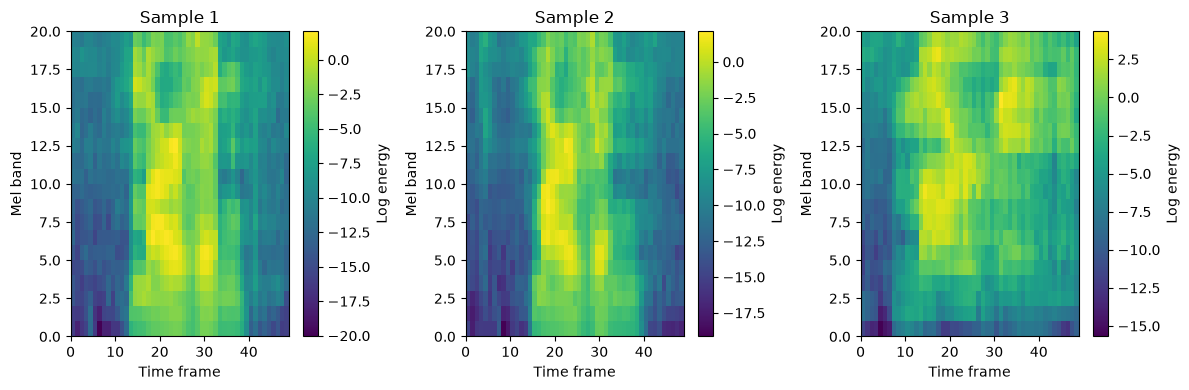

In [11]:
# Visualize Log-Mel spectrograms

fig, axes = plt.subplots(1, min(3, len(features)), figsize=(12, 4))

if len(features) == 1:
    axes = [axes]

for i, (ax, feat) in enumerate(zip(axes, features)):
    mel = feat[:, :, 0].T

    im = ax.imshow(
        mel,
        origin="lower",
        aspect="auto",
        extent=[0, SPEC.n_frames, 0, SPEC.n_mels],
    )

    ax.set_title(f"Sample {i + 1}")
    ax.set_xlabel("Time frame")
    ax.set_ylabel("Mel band")
    fig.colorbar(im, ax=ax, label="Log energy")

plt.tight_layout()
plt.show()

# 5. Augmentation

In [12]:
# Cell 6 — Augmentation

import numpy as np

from training.augment import NoiseBank, augment_waveform, spec_augment_batch
from shared.config import DATA_DIR, KEYWORD

# Use recorded background noise when available
noise_bank = NoiseBank(
    [DATA_DIR / KEYWORD / "noise_real"],
    rng=np.random.default_rng(42),
)

# Waveform augmentation
rng = np.random.default_rng(42)

augmented_audio = [
    augment_waveform(
        audio,
        noise_bank=noise_bank,
        rng=rng,
    )
    for audio in processed
]

# Extract features from augmented waveforms
augmented_features = np.stack([
    features_from_clip(audio)
    for audio in augmented_audio
])

# SpecAugment
spec_augmented_features = spec_augment_batch(
    augmented_features,
    rng=np.random.default_rng(42),
)

print(f"Original waveform : {processed[0].shape}")
print(f"Augmented waveform: {augmented_audio[0].shape}")
print(f"Original features : {features[0].shape}")
print(f"Augmented features: {spec_augmented_features.shape}")
print(f"Real noise clips  : {len(noise_bank)}")

Original waveform : (15680,)
Augmented waveform: (15680,)
Original features : (49, 20, 1)
Augmented features: (3, 49, 20, 1)
Real noise clips  : 2


# 6. Build model

In [ ]:


from training.model import build_dscnn_s

model = build_dscnn_s()

model.summary()

W0000 00:00:1789833790.563620  135829 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "dscnn_s_residual"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mfcc (InputLayer)   │ (None, 49, 20, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 25, 10,    │      2,560 │ mfcc[0][0]        │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 25, 10,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu (ReLU)    │ (None, 25, 10,    │          0 │ stem_bn[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pad          │ (None, 27, 12,    │          0 │ stem_relu[0][0]   │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_dwconv       │ (None, 25, 10,    │        576 │ block1_pad[0][0]  │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_dw_bn        │ (None, 25, 10,    │        256 │ block1_dwconv[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_dw_relu      │ (None, 25, 10,    │          0 │ block1_dw_bn[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pwconv       │ (None, 25, 10,    │      4,096 │ block1_dw_relu[0… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pw_bn        │ (None, 25, 10,    │        256 │ block1_pwconv[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_add (Add)    │ (None, 25, 10,    │          0 │ block1_pw_bn[0][… │
│                     │ 64)               │            │ stem_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_out (ReLU)   │ (None, 25, 10,    │          0 │ block1_add[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pad          │ (None, 27, 12,    │          0 │ block1_out[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_dwconv       │ (None, 25, 10,    │        576 │ block2_pad[0][0]  │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_dw_bn        │ (None, 25, 10,    │        256 │ block2_dwconv[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_dw_relu      │ (None, 25, 10,    │          0 │ block2_dw_bn[0][… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pwconv       │ (None, 25, 10,    │      4,096 │ block2_dw_relu[0… │
│ (Conv2D)            │ 64)               │            │                 

 Total params: 23,747 (92.76 KB)

 Trainable params: 22,595 (88.26 KB)

 Non-trainable params: 1,152 (4.50 KB)

In [14]:
print(f"Model        : DS-CNN-S")
print(f"Input shape  : {model.input_shape[1:]}")
print(f"Output shape : {model.output_shape[1:]}")
print(f"Parameters   : {model.count_params():,}")

Model        : DS-CNN-S
Input shape  : (49, 20, 1)
Output shape : (3,)
Parameters   : 23,747


# 7. Training

In [ ]:
import time
import tensorflow as tf
from tensorflow import keras

from training.train import collect, AugmentedBatches
from training.model import build_dscnn_s

# Baseline configuration — matches training/train.py
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 2e-3
NOISE_CAP = 400

# Collect dataset using the existing training pipeline
train_data, val_data, speakers, gsc_split = collect(
    KEYWORD,
    holdout_speaker=None,
    noise_cap=NOISE_CAP,
)

x_train, y_train, _ = train_data.arrays()
x_val, y_val, _ = val_data.arrays()

print(f"Train samples      : {len(x_train):,}")
print(f"Validation samples : {len(x_val):,}")
print(f"Validation split   : {'Speech Commands testing_list.txt' if gsc_split else 'speaker holdout'}")

  loaded 2000 clips...
  loaded 3000 clips...
  loaded 4000 clips...
  loaded 6000 clips...
  loaded 7000 clips...
  loaded 8000 clips...
  loaded 9000 clips...
  loaded 10000 clips...
  loaded 11000 clips...
  loaded 12000 clips...
  loaded 13000 clips...
  loaded 14000 clips...
  loaded 15000 clips...
  loaded 16000 clips...
  loaded 17000 clips...
  loaded 18000 clips...
  loaded 19000 clips...
  loaded 20000 clips...
  loaded 21000 clips...
  loaded 22000 clips...
  loaded 23000 clips...
Train samples      : 12,703
Validation samples : 11,164
Validation split   : Speech Commands testing_list.txt


In [ ]:
## Setup MLflow
from mlflow.keras import MLflowCallback

import mlflow
from pathlib import Path

MLFLOW_DB = PROJECT_ROOT / "mlflow.db"

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB}")
mlflow.set_experiment("KWS Training")

print(f"MLflow tracking: {MLFLOW_DB}")

mlflow.keras.MlflowCallback()

2026/09/19 16:42:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/19 16:42:26 INFO mlflow.store.db.utils: Updating database tables
2026/09/19 16:42:27 INFO mlflow.tracking.fluent: Experiment with name 'KWS Training' does not exist. Creating a new experiment.


MLflow tracking: /home/sanjeet/ai_workspace/KWS model/sih-2026/mlflow.db


In [26]:
import time
import numpy as np
import mlflow

from training.train import collect, AugmentedBatches
from training.model import build_dscnn_s, N_CLASSES

# =========================
# Model
# =========================

model = build_dscnn_s()


# =========================
# Metric
# =========================

class KeywordRecall(keras.metrics.Metric):

    def __init__(self, name="keyword_recall", **kwargs):
        super().__init__(name=name, **kwargs)
        self.tp = self.add_weight(name="tp", initializer="zeros")
        self.fn = self.add_weight(name="fn", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

        true_keyword = tf.equal(y_true, 0)
        predicted_keyword = tf.equal(y_pred, 0)

        tp = tf.reduce_sum(
            tf.cast(true_keyword & predicted_keyword, self.dtype)
        )
        fn = tf.reduce_sum(
            tf.cast(true_keyword & ~predicted_keyword, self.dtype)
        )

        self.tp.assign_add(tp)
        self.fn.assign_add(fn)

    def result(self):
        return self.tp / (self.tp + self.fn + keras.backend.epsilon())

    def reset_state(self):
        self.tp.assign(0)
        self.fn.assign(0)


# =========================
# Compile
# =========================

model.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", KeywordRecall()],
)


# =========================
# Class weights
# =========================

counts = {
    i: int((y_train == i).sum())
    for i in range(N_CLASSES)
}

max_c = max(counts.values()) or 1

class_weight = {
    i: max_c / max(1, counts[i])
    for i in range(N_CLASSES)
}

class_weight[0] *= 1.35


# =========================
# Callbacks
# =========================

class EpochTimer(keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.perf_counter() - self._epoch_start
        self.epoch_times.append(elapsed)


class BestWakeCallback(keras.callbacks.Callback):

    def __init__(
        self,
        filepath,
        patience=12,
        min_val_acc=0.90,
    ):
        super().__init__()

        self.filepath = filepath
        self.patience = patience
        self.min_val_acc = min_val_acc

        self.best = -np.inf
        self.best_weights = None
        self.wait = 0

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        val_acc = logs.get("val_accuracy")
        val_recall = logs.get("val_keyword_recall")

        if val_acc is None or val_recall is None:
            return

        if val_acc >= self.min_val_acc:

            if val_recall > self.best:

                self.best = val_recall
                self.best_weights = self.model.get_weights()
                self.wait = 0

                # Save best model immediately
                self.model.save(self.filepath)

                print(
                    f"\n  → New best keyword recall: "
                    f"{val_recall:.4f} — model saved"
                )

            else:
                self.wait += 1

                if self.wait >= self.patience:
                    self.model.stop_training = True

    def on_train_end(self, logs=None):

        if self.best_weights is not None:
            self.model.set_weights(self.best_weights)


# =========================
# Dataset generator
# =========================

generator = AugmentedBatches(
    x_train,
    y_train,
    BATCH_SIZE,
)

steps_per_epoch = max(
    1,
    len(x_train) // BATCH_SIZE,
)

dataset = (
    tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(
                shape=(None, *x_train.shape[1:]),
                dtype=tf.float32,
            ),
            tf.TensorSpec(
                shape=(None,),
                dtype=tf.int32,
            ),
        ),
    )
    .repeat()
    .prefetch(tf.data.AUTOTUNE)
)




model_dir = PROJECT_ROOT / "models"
model_dir.mkdir(exist_ok=True)

best_model_path = model_dir / f"{KEYWORD}_best.keras"

# =========================
# Training
# =========================

with mlflow.start_run(run_name=f"{KEYWORD}_DSCNN_S"):

    # Parameters
    mlflow.log_params({
        "keyword": KEYWORD,
        "model": "DS-CNN-S",
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "noise_cap": NOISE_CAP,
        "feature_shape": str(x_train.shape[1:]),
        "n_classes": N_CLASSES,
        "train_samples": len(x_train),
        "val_samples": len(x_val),

        # Model size information
        "total_parameters": model.count_params(),

        # Hardware used for training only
        "training_device": (
            tf.config.list_physical_devices("GPU")[0].name
            if tf.config.list_physical_devices("GPU")
            else "CPU"
        ),
    })

    # Callbacks
    timer = EpochTimer()
    mlflow_callback = MLflowCallback()

    callbacks = [
        timer,
        mlflow_callback,

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=6,
            min_lr=1e-5,
            verbose=0,
        ),

        BestWakeCallback(
            filepath=best_model_path,
            patience=12,
            min_val_acc=0.90,
        ),
    ]

    # Train
    history = model.fit(
        dataset,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        steps_per_epoch=steps_per_epoch,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1,
    )

    # =========================
    # Best training metrics
    # =========================

    val_recall_history = history.history.get(
        "val_keyword_recall", []
    )

    val_accuracy_history = history.history.get(
        "val_accuracy", []
    )

    val_loss_history = history.history.get(
        "val_loss", []
    )

    best_epoch = (
        int(np.argmax(val_recall_history)) + 1
        if val_recall_history
        else 0
    )

    best_val_recall = (
        max(val_recall_history)
        if val_recall_history
        else 0.0
    )

    best_val_accuracy = (
        max(val_accuracy_history)
        if val_accuracy_history
        else 0.0
    )

    best_val_loss = (
        min(val_loss_history)
        if val_loss_history
        else 0.0
    )

    # Run-level summary metrics
    mlflow.log_metrics({
        "best_val_keyword_recall": float(best_val_recall),
        "best_val_accuracy": float(best_val_accuracy),
        "best_val_loss": float(best_val_loss),
        "mean_epoch_time_sec": float(
            np.mean(timer.epoch_times)
        ),
        "best_epoch": float(best_epoch),
    })

    # =========================
    # Log best model artifact
    # =========================

    if best_model_path.exists():

        mlflow.log_artifact(
            str(best_model_path),
            artifact_path="model",
        )

        model_path = best_model_path

    else:
        # Fallback for very short runs where
        # val_accuracy never reached the 0.90 gate.
        model_path = (
            PROJECT_ROOT
            / "models"
            / f"{KEYWORD}_final.keras"
        )

        model.save(model_path)

        mlflow.log_artifact(
            str(model_path),
            artifact_path="model",
        )

    # =========================
    # Summary
    # =========================

    print()
    print("Training complete")
    print(f"Best val keyword recall : {best_val_recall:.4f}")
    print(f"Best val accuracy       : {best_val_accuracy:.4f}")
    print(f"Best val loss           : {best_val_loss:.4f}")
    print(f"Best epoch              : {best_epoch}")
    print(
        f"Mean epoch time        : "
        f"{np.mean(timer.epoch_times):.2f} s"
    )
    print(f"Model                   : {model_path}")

Epoch 1/50


/home/sanjeet/ai_workspace/KWS model/sih-2026/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


396/396 ━━━━━━━━━━━━━━━━━━━━ 90s 210ms/step - accuracy: 0.8303 - keyword_recall: 0.9054 - loss: 0.6637 - val_accuracy: 0.7413 - val_keyword_recall: 0.5128 - val_loss: 0.5695 - learning_rate: 0.0020
Epoch 2/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 75s 189ms/step - accuracy: 0.8841 - keyword_recall: 0.9409 - loss: 0.4360 - val_accuracy: 0.9444 - val_keyword_recall: 0.3744 - val_loss: 0.1628 - learning_rate: 0.0020
Epoch 3/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 74s 186ms/step - accuracy: 0.8939 - keyword_recall: 0.9457 - loss: 0.4184 - val_accuracy: 0.9618 - val_keyword_recall: 0.2000 - val_loss: 0.1342 - learning_rate: 0.0020
Epoch 4/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 76s 191ms/step - accuracy: 0.9088 - keyword_recall: 0.9536 - loss: 0.3372 - val_accuracy: 0.9192 - val_keyword_recall: 0.5641 - val_loss: 0.2377 - learning_rate: 0.0020
Epoch 5/50
396/396 ━━━━━━━━━━━━━━━━━━━━ 75s 191ms/step - accuracy: 0.9212 - keyword_recall: 0.9600 - loss: 0.2996 - val_accuracy: 0.9786 - val_keyword_recall: 0.0667 - val_los

# Save history and config

In [27]:
import json

with open(PROJECT_ROOT / "models" / f"{KEYWORD}_history.json", "w") as f:
    json.dump(history.history, f)

In [30]:
import json

training_config = {
    "keyword": KEYWORD,
    "model": "DS-CNN-S",
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "noise_cap": NOISE_CAP,
    "feature_shape": list(x_train.shape[1:]),
    "n_classes": N_CLASSES,
    "optimizer": "Adam",
    "dtype": "float32",
    # "best_model": str(best_model_path),
}

with open(PROJECT_ROOT / "models" / f"{KEYWORD}_training_config.json", "w") as f:
    json.dump(training_config, f, indent=2)

In [31]:
val_recall = history.history["val_keyword_recall"]
val_acc = history.history["val_accuracy"]

best_epoch = max(range(len(val_recall)), key=lambda i: val_recall[i])

print(f"Best epoch: {best_epoch + 1}")
print(f"Best val keyword recall: {val_recall[best_epoch]:.4f}")
print(f"Val accuracy at best epoch: {val_acc[best_epoch]:.4f}")

Best epoch: 38
Best val keyword recall: 0.8462
Val accuracy at best epoch: 0.9874


# Convert keras to tflite and save
Keras file --> contains extra info to allow furthur training of same model without retraining it from scratch
tflite --> smaller file, for deployment, does not contain additional things.

In [ ]:
from pathlib import Path
import tensorflow as tf

# Reuse PROJECT_ROOT from the configuration cell.
model_path = PROJECT_ROOT / "models" / f"{KEYWORD}.keras"
output_path = PROJECT_ROOT / "models" / f"{KEYWORD}.float.tflite"

if not model_path.exists():
    raise FileNotFoundError(f"Keras model not found: {model_path}")

# Compile state and custom training metrics are not needed for inference export.
model = tf.keras.models.load_model(
    model_path,
    compile=False,
)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
output_path.write_bytes(tflite_model)

# Verify that the generated artifact can be loaded and has the expected contract.
interpreter = tf.lite.Interpreter(model_path=str(output_path))
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print(f"Saved: {output_path}")
print(f"Size: {output_path.stat().st_size / 1024:.2f} KB")
print(f"Input : {input_details['shape']} {input_details['dtype']}")
print(f"Output: {output_details['shape']} {output_details['dtype']}")